In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/Papaya_Leaf_Disease_Classification")
PREP_ROOT = PROJECT_ROOT / "prepared_data_v1"

YOLO_ROOT = PREP_ROOT / "yolo_dataset"
CNN_CROP_ROOT = PREP_ROOT / "cnn_dataset"

# Dataset mới: CNN train trên toàn ảnh
FULL_CNN_ROOT = PREP_ROOT / "cnn_full_image_dataset"

# Nơi lưu model EfficientNetB2 CNN-only
MODEL_ROOT = PROJECT_ROOT / "Model" / "CNN_Full_Image_Baselines"
RUN_DIR = MODEL_ROOT / "EfficientNetB2_CNN_Only"

RUN_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("YOLO_ROOT    :", YOLO_ROOT)
print("CNN_CROP_ROOT:", CNN_CROP_ROOT)
print("FULL_CNN_ROOT:", FULL_CNN_ROOT)
print("RUN_DIR      :", RUN_DIR)

Mounted at /content/drive
PROJECT_ROOT : /content/drive/MyDrive/Papaya_Leaf_Disease_Classification
YOLO_ROOT    : /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/prepared_data_v1/yolo_dataset
CNN_CROP_ROOT: /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/prepared_data_v1/cnn_dataset
FULL_CNN_ROOT: /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/prepared_data_v1/cnn_full_image_dataset
RUN_DIR      : /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/CNN_Full_Image_Baselines/EfficientNetB2_CNN_Only


In [ ]:
import shutil
from collections import Counter
import pandas as pd

CLASS_NAMES = ["Anthracnose", "BacterialSpot", "Curl", "Healthy", "RingSpot"]

YOLO_CLASSES = ["Anthracnose", "BacterialSpot", "Curl", "RingSpot"]
YOLO_ID_TO_CLASS = {i: name for i, name in enumerate(YOLO_CLASSES)}

VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

REBUILD_FULL_IMAGE_DATASET = True

if REBUILD_FULL_IMAGE_DATASET and FULL_CNN_ROOT.exists():
    shutil.rmtree(FULL_CNN_ROOT)

for split in ["train", "val", "test"]:
    for cls in CLASS_NAMES:
        (FULL_CNN_ROOT / split / cls).mkdir(parents=True, exist_ok=True)

def list_images(folder):
    folder = Path(folder)
    return sorted([
        p for p in folder.rglob("*")
        if p.is_file() and p.suffix.lower() in VALID_EXTS
    ])

def get_class_from_yolo_label(label_path):
    label_path = Path(label_path)

    if not label_path.exists():
        return None

    cls_ids = []

    with open(label_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            parts = line.strip().split()

            if len(parts) != 5:
                continue

            try:
                cls_id = int(float(parts[0]))
                if cls_id in YOLO_ID_TO_CLASS:
                    cls_ids.append(cls_id)
            except Exception:
                pass

    if len(cls_ids) == 0:
        return None

    # Nếu 1 ảnh có nhiều bbox, lấy class xuất hiện nhiều nhất làm nhãn toàn ảnh
    main_cls_id = Counter(cls_ids).most_common(1)[0][0]
    return YOLO_ID_TO_CLASS[main_cls_id]

records = []
skipped_records = []

for split in ["train", "val", "test"]:
    print(f"\nProcessing split: {split}")

    # ============================================================
    # 1. 4 lớp bệnh: lấy từ YOLO split
    # ============================================================

    yolo_img_dir = YOLO_ROOT / "images" / split
    yolo_lbl_dir = YOLO_ROOT / "labels" / split

    assert yolo_img_dir.exists(), f"Không tìm thấy: {yolo_img_dir}"
    assert yolo_lbl_dir.exists(), f"Không tìm thấy: {yolo_lbl_dir}"

    for img_path in list_images(yolo_img_dir):
        label_path = yolo_lbl_dir / f"{img_path.stem}.txt"
        cls_name = get_class_from_yolo_label(label_path)

        if cls_name is None:
            skipped_records.append({
                "split": split,
                "source": "yolo_full_image",
                "image_path": str(img_path),
                "label_path": str(label_path),
                "reason": "missing_or_invalid_yolo_label"
            })
            continue

        dst_path = FULL_CNN_ROOT / split / cls_name / img_path.name
        shutil.copy2(img_path, dst_path)

        records.append({
            "split": split,
            "class_name": cls_name,
            "source": "yolo_full_image",
            "src_image_path": str(img_path),
            "dst_image_path": str(dst_path),
            "label_path": str(label_path)
        })

    # ============================================================
    # 2. Healthy: lấy từ cnn_dataset split Healthy
    # ============================================================

    healthy_dir = CNN_CROP_ROOT / split / "Healthy"

    assert healthy_dir.exists(), f"Không tìm thấy Healthy dir: {healthy_dir}"

    for img_path in list_images(healthy_dir):
        dst_path = FULL_CNN_ROOT / split / "Healthy" / img_path.name
        shutil.copy2(img_path, dst_path)

        records.append({
            "split": split,
            "class_name": "Healthy",
            "source": "cnn_healthy_full_image",
            "src_image_path": str(img_path),
            "dst_image_path": str(dst_path),
            "label_path": None
        })

manifest_df = pd.DataFrame(records)
skipped_df = pd.DataFrame(skipped_records)

manifest_df.to_csv(FULL_CNN_ROOT / "manifest.csv", index=False, encoding="utf-8-sig")
skipped_df.to_csv(FULL_CNN_ROOT / "skipped.csv", index=False, encoding="utf-8-sig")

print("\nSaved full-image CNN dataset to:")
print(FULL_CNN_ROOT)

count_df = (
    manifest_df
    .groupby(["split", "class_name"])
    .size()
    .reset_index(name="count")
)

display(count_df)

print("\nSkipped records:")
display(skipped_df.head())


Processing split: train

Processing split: val

Processing split: test

Saved full-image CNN dataset to:
/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/prepared_data_v1/cnn_full_image_dataset


,split,class_name,count
0,test,Anthracnose,54
1,test,BacterialSpot,69
2,test,Curl,54
3,test,Healthy,34
4,test,RingSpot,80
5,train,Anthracnose,248
6,train,BacterialSpot,320
7,train,Curl,253
8,train,Healthy,160
9,train,RingSpot,373



Skipped records:


""


In [ ]:
import os
import json
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print("Không bật được memory growth:", e)

print("TensorFlow:", tf.__version__)
print("GPU count :", len(gpus))

TensorFlow: 2.20.0
GPU count : 1


In [ ]:
TRAIN_DIR = FULL_CNN_ROOT / "train"
VAL_DIR = FULL_CNN_ROOT / "val"
TEST_DIR = FULL_CNN_ROOT / "test"

assert TRAIN_DIR.exists()
assert VAL_DIR.exists()
assert TEST_DIR.exists()

IMG_SIZE = 260
BATCH_SIZE = 32

EPOCHS = 15
LEARNING_RATE = 1e-3
DROPOUT_RATE = 0.30

print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR  :", VAL_DIR)
print("TEST_DIR :", TEST_DIR)

TRAIN_DIR: /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/prepared_data_v1/cnn_full_image_dataset/train
VAL_DIR  : /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/prepared_data_v1/cnn_full_image_dataset/val
TEST_DIR : /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/prepared_data_v1/cnn_full_image_dataset/test


In [ ]:
!pip -q install pandas==2.2.2 pillow==11.3.0 scikit-learn matplotlib

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/Papaya_Leaf_Disease_Classification")
PREP_ROOT = PROJECT_ROOT / "prepared_data_v1"

# Dataset toàn ảnh đã tạo
CNN_ROOT = PREP_ROOT / "cnn_full_image_dataset"

TRAIN_DIR = CNN_ROOT / "train"
VAL_DIR   = CNN_ROOT / "val"
TEST_DIR  = CNN_ROOT / "test"

RUN_DIR = PROJECT_ROOT / "Model" / "CNN_Full_Image_Baselines" / "EfficientNetB2_Fair"
RUN_DIR.mkdir(parents=True, exist_ok=True)

print("CNN_ROOT :", CNN_ROOT)
print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR  :", VAL_DIR)
print("TEST_DIR :", TEST_DIR)
print("RUN_DIR  :", RUN_DIR)

assert TRAIN_DIR.exists()
assert VAL_DIR.exists()
assert TEST_DIR.exists()

Mounted at /content/drive
CNN_ROOT : /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/prepared_data_v1/cnn_full_image_dataset
TRAIN_DIR: /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/prepared_data_v1/cnn_full_image_dataset/train
VAL_DIR  : /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/prepared_data_v1/cnn_full_image_dataset/val
TEST_DIR : /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/prepared_data_v1/cnn_full_image_dataset/test
RUN_DIR  : /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/CNN_Full_Image_Baselines/EfficientNetB2_Fair


In [ ]:
import os
import json
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except:
            pass

CLASS_NAMES = ["Anthracnose", "BacterialSpot", "Curl", "Healthy", "RingSpot"]
NUM_CLASSES = len(CLASS_NAMES)

IMG_SIZE = 260
BATCH_SIZE = 32

STAGE1_EPOCHS = 8
STAGE2_EPOCHS = 20

STAGE1_LR = 1e-3
STAGE2_LR = 5e-5

DROPOUT_RATE = 0.35
UNFREEZE_LAST_N = 60

print("TensorFlow:", tf.__version__)
print("GPU count :", len(gpus))

TensorFlow: 2.20.0
GPU count : 1


In [ ]:
VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

def count_images(folder):
    folder = Path(folder)
    return len([
        p for p in folder.rglob("*")
        if p.is_file() and p.suffix.lower() in VALID_EXTS
    ])

rows = []

for split_name, split_dir in [("train", TRAIN_DIR), ("val", VAL_DIR), ("test", TEST_DIR)]:
    for cls in CLASS_NAMES:
        n = count_images(split_dir / cls)
        rows.append({
            "split": split_name,
            "class_name": cls,
            "num_images": n
        })

count_df = pd.DataFrame(rows)
display(count_df)

count_df.to_csv(RUN_DIR / "dataset_count.csv", index=False, encoding="utf-8-sig")

train_counts = {
    cls: count_images(TRAIN_DIR / cls)
    for cls in CLASS_NAMES
}

total_train = sum(train_counts.values())

class_weights = {}
for idx, cls in enumerate(CLASS_NAMES):
    class_weights[idx] = total_train / (NUM_CLASSES * train_counts[cls])

print("Train counts:", train_counts)
print("Class weights:", {CLASS_NAMES[k]: round(v, 4) for k, v in class_weights.items()})

,split,class_name,num_images
0,train,Anthracnose,248
1,train,BacterialSpot,320
2,train,Curl,253
3,train,Healthy,160
4,train,RingSpot,373
5,val,Anthracnose,53
6,val,BacterialSpot,69
7,val,Curl,54
8,val,Healthy,34
9,val,RingSpot,80


Train counts: {'Anthracnose': 248, 'BacterialSpot': 320, 'Curl': 253, 'Healthy': 160, 'RingSpot': 373}
Class weights: {'Anthracnose': 1.0919, 'BacterialSpot': 0.8462, 'Curl': 1.0704, 'Healthy': 1.6925, 'RingSpot': 0.726}


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

train_ds_raw = train_ds_raw.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Found 1354 files belonging to 5 classes.
Found 290 files belonging to 5 classes.
Found 291 files belonging to 5 classes.


In [ ]:
stage1_best = RUN_DIR / "best_stage1.keras"
stage1_history = RUN_DIR / "history_stage1.csv"

callbacks_stage1 = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(stage1_best),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    keras.callbacks.CSVLogger(
        filename=str(stage1_history),
        append=False
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    keras.callbacks.TerminateOnNaN()
]

history1 = model.fit(
    train_ds_raw,
    validation_data=val_ds,
    epochs=STAGE1_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks_stage1,
    verbose=1
)

Epoch 1/8
42/43 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.7800 - loss: 0.5755
Epoch 1: val_loss improved from None to 0.55071, saving model to /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/CNN_Full_Image_Baselines/EfficientNetB2_Fair/best_stage1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/CNN_Full_Image_Baselines/EfficientNetB2_Fair/best_stage1.keras
43/43 ━━━━━━━━━━━━━━━━━━━━ 27s 417ms/step - accuracy: 0.7888 - loss: 0.5644 - val_accuracy: 0.8172 - val_loss: 0.5507 - learning_rate: 0.0010
Epoch 2/8
42/43 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.8066 - loss: 0.5620
Epoch 2: val_loss improved from 0.55071 to 0.52105, saving model to /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/CNN_Full_Image_Baselines/EfficientNetB2_Fair/best_stage1.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/CNN_Full_Image_Baselines/EfficientNetB2_

In [ ]:
model = keras.models.load_model(stage1_best)

# Tìm backbone EfficientNet
backbone_layer = None
for layer in model.layers:
    if "efficientnet" in layer.name.lower():
        backbone_layer = layer
        break

assert backbone_layer is not None, "Không tìm thấy EfficientNet backbone."

backbone_layer.trainable = True

# Chỉ mở một số layer cuối để fine-tune công bằng, tránh overfit quá mạnh
for layer in backbone_layer.layers[:-UNFREEZE_LAST_N]:
    layer.trainable = False

# BatchNorm giữ frozen để fine-tune ổn định
for layer in backbone_layer.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print("Backbone:", backbone_layer.name)
print("Trainable layers:", sum(1 for l in backbone_layer.layers if l.trainable))
print("Frozen layers   :", sum(1 for l in backbone_layer.layers if not l.trainable))

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=STAGE2_LR),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
)

stage2_best = RUN_DIR / "best_stage2.keras"
final_best = RUN_DIR / "best_model.keras"
final_last = RUN_DIR / "last_model.keras"
stage2_history = RUN_DIR / "history_stage2.csv"

callbacks_stage2 = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(stage2_best),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    keras.callbacks.CSVLogger(
        filename=str(stage2_history),
        append=False
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    keras.callbacks.TerminateOnNaN()
]

history2 = model.fit(
    train_ds_raw,
    validation_data=val_ds,
    epochs=STAGE2_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks_stage2,
    verbose=1
)

model = keras.models.load_model(stage2_best)
model.save(final_best)
model.save(final_last)

print("Saved final best:", final_best)
print("Saved final last :", final_last)

Backbone: efficientnetb2
Trainable layers: 47
Frozen layers   : 293
Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 686ms/step - accuracy: 0.8187 - loss: 0.4667
Epoch 1: val_loss improved from None to 0.33528, saving model to /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/CNN_Full_Image_Baselines/EfficientNetB2_Fair/best_stage2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/CNN_Full_Image_Baselines/EfficientNetB2_Fair/best_stage2.keras
43/43 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.8338 - loss: 0.4281 - val_accuracy: 0.8690 - val_loss: 0.3353 - learning_rate: 5.0000e-05
Epoch 2/20
42/43 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.8807 - loss: 0.3168
Epoch 2: val_loss improved from 0.33528 to 0.28994, saving model to /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/CNN_Full_Image_Baselines/EfficientNetB2_Fair/best_stage2.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Papaya_Lea

,epoch,accuracy,loss,val_accuracy,val_loss,stage,epoch_global
0,0,0.788774,0.564412,0.817241,0.550708,stage1,1
1,1,0.802806,0.544344,0.837931,0.521052,stage1,2
2,2,0.819055,0.525474,0.817241,0.514859,stage1,3
3,3,0.822009,0.521590,0.827586,0.500969,stage1,4
4,4,0.823486,0.502925,0.834483,0.492090,stage1,5
5,5,0.830871,0.488896,0.837931,0.476575,stage1,6
6,6,0.822009,0.483711,0.844828,0.464759,stage1,7
7,7,0.833087,0.465195,0.848276,0.449518,stage1,8
8,0,0.833826,0.428095,0.868966,0.335277,stage2,9
9,1,0.875923,0.322311,0.900000,0.289941,stage2,10


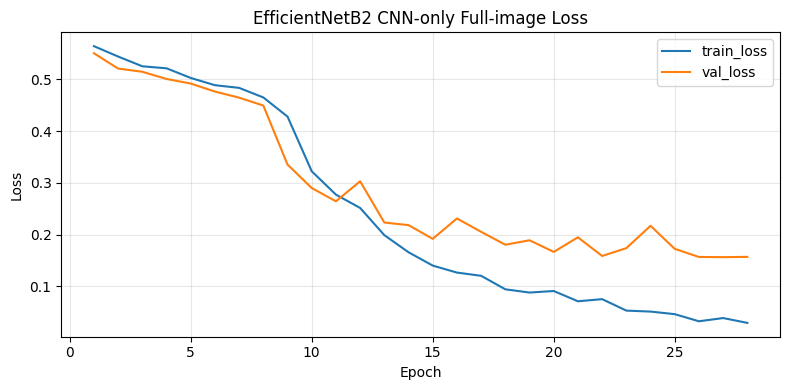

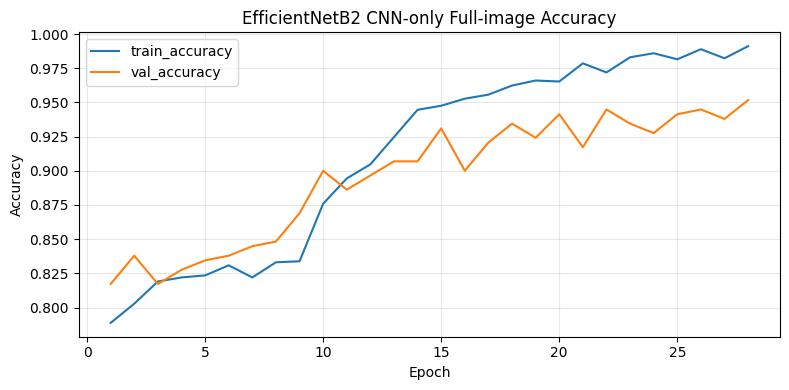

In [ ]:
hist1 = pd.read_csv(stage1_history)
hist1["stage"] = "stage1"
hist1["epoch_global"] = np.arange(1, len(hist1) + 1)

hist2 = pd.read_csv(stage2_history)
hist2["stage"] = "stage2"
hist2["epoch_global"] = np.arange(len(hist1) + 1, len(hist1) + len(hist2) + 1)

hist_df = pd.concat([hist1, hist2], ignore_index=True)
hist_df.to_csv(RUN_DIR / "history_combined.csv", index=False, encoding="utf-8-sig")

display(hist_df)

plt.figure(figsize=(8, 4))
plt.plot(hist_df["epoch_global"], hist_df["loss"], label="train_loss")
plt.plot(hist_df["epoch_global"], hist_df["val_loss"], label="val_loss")
plt.title("EfficientNetB2 CNN-only Full-image Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RUN_DIR / "loss_curve.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(hist_df["epoch_global"], hist_df["accuracy"], label="train_accuracy")
plt.plot(hist_df["epoch_global"], hist_df["val_accuracy"], label="val_accuracy")
plt.title("EfficientNetB2 CNN-only Full-image Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RUN_DIR / "accuracy_curve.png", dpi=200)
plt.show()

In [ ]:
model = keras.models.load_model(final_best)

y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)

    y_true.extend(labels.numpy().tolist())
    y_pred.extend(preds.tolist())
    y_prob.extend(probs.tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

acc = accuracy_score(y_true, y_pred)

macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print("Accuracy        :", acc)
print("Macro Precision :", macro_p)
print("Macro Recall    :", macro_r)
print("Macro F1        :", macro_f1)
print("Weighted F1     :", weighted_f1)

Accuracy        : 0.9278350515463918
Macro Precision : 0.9317002226110386
Macro Recall    : 0.9285526191152789
Macro F1        : 0.9293195977595674
Weighted F1     : 0.9273944819302771


,precision,recall,f1-score,support
Anthracnose,0.909091,0.925926,0.917431,54.000000
BacterialSpot,0.951613,0.855072,0.900763,69.000000
Curl,0.964286,1.000000,0.981818,54.000000
Healthy,0.939394,0.911765,0.925373,34.000000
RingSpot,0.894118,0.950000,0.921212,80.000000
accuracy,0.927835,0.927835,0.927835,0.927835
macro avg,0.931700,0.928553,0.929320,291.000000
weighted avg,0.928840,0.927835,0.927394,291.000000


,Anthracnose,BacterialSpot,Curl,Healthy,RingSpot
Anthracnose,50,2,0,0,2
BacterialSpot,1,59,1,2,6
Curl,0,0,54,0,0
Healthy,2,0,0,31,1
RingSpot,2,1,1,0,76


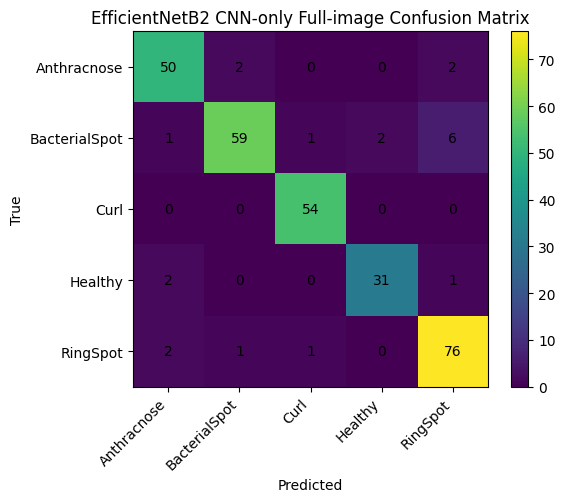

In [ ]:
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()
display(report_df)

report_df.to_csv(RUN_DIR / "classification_report.csv", encoding="utf-8-sig")

cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
cm_df = pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES)
display(cm_df)

cm_df.to_csv(RUN_DIR / "confusion_matrix.csv", encoding="utf-8-sig")

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("EfficientNetB2 CNN-only Full-image Confusion Matrix")
plt.colorbar()

ticks = np.arange(NUM_CLASSES)
plt.xticks(ticks, CLASS_NAMES, rotation=45, ha="right")
plt.yticks(ticks, CLASS_NAMES)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(RUN_DIR / "confusion_matrix.png", dpi=200)
plt.show()

In [ ]:
summary = {
    "model": "EfficientNetB2_CNN_Only_Full_Image_Fair",
    "dataset": str(CNN_ROOT),
    "train_dir": str(TRAIN_DIR),
    "val_dir": str(VAL_DIR),
    "test_dir": str(TEST_DIR),
    "num_test_samples": int(len(y_true)),
    "accuracy": float(acc),
    "macro_precision": float(macro_p),
    "macro_recall": float(macro_r),
    "macro_f1": float(macro_f1),
    "weighted_precision": float(weighted_p),
    "weighted_recall": float(weighted_r),
    "weighted_f1": float(weighted_f1),
    "best_model_path": str(final_best),
    "last_model_path": str(final_last),
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S")
}

with open(RUN_DIR / "test_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print(json.dumps(summary, indent=2, ensure_ascii=False))

{
  "model": "EfficientNetB2_CNN_Only_Full_Image_Fair",
  "dataset": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/prepared_data_v1/cnn_full_image_dataset",
  "train_dir": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/prepared_data_v1/cnn_full_image_dataset/train",
  "val_dir": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/prepared_data_v1/cnn_full_image_dataset/val",
  "test_dir": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/prepared_data_v1/cnn_full_image_dataset/test",
  "num_test_samples": 291,
  "accuracy": 0.9278350515463918,
  "macro_precision": 0.9317002226110386,
  "macro_recall": 0.9285526191152789,
  "macro_f1": 0.9293195977595674,
  "weighted_precision": 0.9288399783127771,
  "weighted_recall": 0.9278350515463918,
  "weighted_f1": 0.9273944819302771,
  "best_model_path": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/CNN_Full_Image_Baselines/EfficientNetB2_Fair/best_model.keras",
  "last_model_path": "/c